In [106]:
import math
import matplotlib.pyplot as plt

# lungimi in milimetri
lungime_brat_1 = 400
lungime_brat_2 = 400
lungime_brat_legatura = 100
lungime_brat_arc = 80
lungime_arc_minima = 85
lungime_arc_maxima = lungime_arc_minima + 143

# greutati in grame
greutate_brat_1 = 150
greutate_brat_2 = 150
greutate_brat_legatura = 40
greutate_brat_paralel = 80
greutate_brat_arc = 20

# roti dintate
raport_melc = 40
randament_melc = 0.4
raport_reductor = 19
randament_reductor = 0.8
factor_siguranta_motor = 3

# forta arcului
F0_arc = 1.96 # N forta initiala a arcului
R_arc = 0.14 # N/mm constanta arcului

# pozitie baza arc
x_baza_arc = -lungime_brat_arc
y_baza_arc = -lungime_arc_minima + (lungime_arc_minima - lungime_arc_maxima) / 2 - 10

In [107]:
class Brat:
    def __init__(self, lungime, greutate, baza = (0, 0), unghi = 0):
        self.lungime = lungime
        self.greutate = greutate
        self.baza = baza
        self.unghi = unghi
        self.pozitie_varf = (self.baza[0] + self.lungime * math.cos(math.radians(unghi)), self.baza[1] + self.lungime * math.sin(math.radians(unghi)))
        self.pozitie_centru_greutate = (self.baza[0] + (self.lungime / 2) * math.cos(math.radians(unghi)), self.baza[1] + (self.lungime / 2) * math.sin(math.radians(unghi)))
    
    def afisare(self, color='b'):
        plt.plot([self.baza[0], self.pozitie_varf[0]], [self.baza[1], self.pozitie_varf[1]], color)

class Arc:
    def __init__(self, F0, R, L0, Ln, unghi):
        self.brat = Brat(lungime = lungime_brat_arc, greutate = greutate_brat_arc, baza = (0,0), unghi = unghi)
        self.varf_arc = self.brat.pozitie_varf
        self.baza_arc = (x_baza_arc, y_baza_arc)
        self.lungime_arc_actuala = math.sqrt((self.brat.pozitie_varf[0] - self.baza_arc[0])**2 + (self.brat.pozitie_varf[1] - self.baza_arc[1])**2)
        if self.lungime_arc_actuala < lungime_arc_minima:
            print("lungime actuala:", self.lungime_arc_actuala, "minima:", lungime_arc_minima)
            raise ValueError('Lungimea arcului este mai mica decat lungimea minima!')
        if self.lungime_arc_actuala > lungime_arc_maxima:
            print("lungime actuala:", self.lungime_arc_actuala, "maxima:", lungime_arc_maxima)
            raise ValueError('Lungimea arcului este mai mare decat lungimea maxima!')
        
        self.forta_arc = F0 + R * (self.lungime_arc_actuala - L0) # N
        delta_xy = (self.varf_arc[0] - self.baza_arc[0], self.varf_arc[1] - self.baza_arc[1]) # mm
        self.forta_varf = (self.forta_arc * delta_xy[0] / self.lungime_arc_actuala, self.forta_arc * delta_xy[1] / self.lungime_arc_actuala) # N
        self.moment = (self.forta_varf[0] * self.varf_arc[1] - self.forta_varf[1] * self.varf_arc[0]) / 1000 # Nm
    
    def afisare(self):
        self.brat.afisare('c')
        plt.plot([self.baza_arc[0], self.varf_arc[0]], [self.baza_arc[1], self.varf_arc[1]], 'c--')

class Bariera:
    def __init__(self, unghi):
        self.brat_1 = Brat(lungime = lungime_brat_1, greutate = greutate_brat_1, baza = (0, 0), unghi = unghi)
        self.brat_2 = Brat(lungime = lungime_brat_2, greutate = greutate_brat_2, baza = self.brat_1.pozitie_varf, unghi = 0)
        self.brat_legatura = Brat(lungime = lungime_brat_legatura, greutate = greutate_brat_legatura, baza = self.brat_1.pozitie_varf, unghi = 45 + 90)
        self.brat_paralel = Brat(lungime = lungime_brat_1, greutate = greutate_brat_paralel, baza = (self.brat_legatura.lungime * math.cos(math.radians(45 + 90)), self.brat_legatura.lungime * math.sin(math.radians(45 + 90))), unghi = unghi)
        self.arc = Arc(F0 = F0_arc, R = R_arc, L0 = lungime_arc_minima, Ln = lungime_arc_maxima, unghi = unghi + 90 + 45)

        # centru de greutate total
        self.greutate_totala = self.brat_1.greutate + self.brat_2.greutate + self.brat_paralel.greutate + self.brat_legatura.greutate
        self.centru_greutate_total = (
            (self.brat_1.greutate * self.brat_1.pozitie_centru_greutate[0] +
            self.brat_2.greutate * self.brat_2.pozitie_centru_greutate[0] +
            self.brat_paralel.greutate * self.brat_paralel.pozitie_centru_greutate[0] +
            self.brat_legatura.greutate * self.brat_legatura.pozitie_centru_greutate[0] + 
            self.arc.brat.greutate * self.arc.brat.pozitie_centru_greutate[0]) / self.greutate_totala,
            (self.brat_1.greutate * self.brat_1.pozitie_centru_greutate[1] +
            self.brat_2.greutate * self.brat_2.pozitie_centru_greutate[1] +
            self.brat_paralel.greutate * self.brat_paralel.pozitie_centru_greutate[1] +
            self.brat_legatura.greutate * self.brat_legatura.pozitie_centru_greutate[1] + 
            self.arc.brat.greutate * self.arc.brat.pozitie_centru_greutate[1]) / self.greutate_totala
        )

        # cuplu
        distanta_orizontala = self.centru_greutate_total[0] / 1000
        forta = self.greutate_totala * 9.81 / 1000
        self.moment_bariera = forta * distanta_orizontala
        self.moment_ax = self.moment_bariera - self.arc.moment
        self.cuplu_motor = self.moment_ax / (randament_melc * raport_melc * randament_reductor * raport_reductor) * factor_siguranta_motor

    def afisare(self):
        plt.title(f'Bariera la unghiul de {self.brat_1.unghi} grade')
        plt.plot(self.centru_greutate_total[0], self.centru_greutate_total[1], 'ko')
        self.brat_1.afisare('b')
        self.brat_2.afisare('r')
        self.brat_legatura.afisare('g')
        self.brat_paralel.afisare('m')
        self.arc.afisare()
        plt.grid()
        plt.legend(['Centru greutate', 'Brat 1', 'Brat 2', 'Brat legatura', 'Brat paralel', 'Brat arc', 'Arc'])
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()


Forta necesara motor: 0.001011 Nm
Forta necesara motor: 0.010365 Kgcm


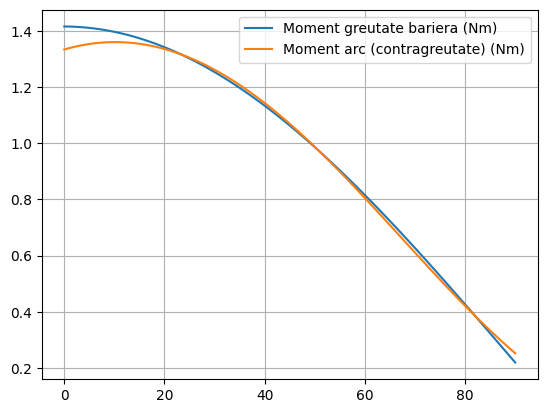

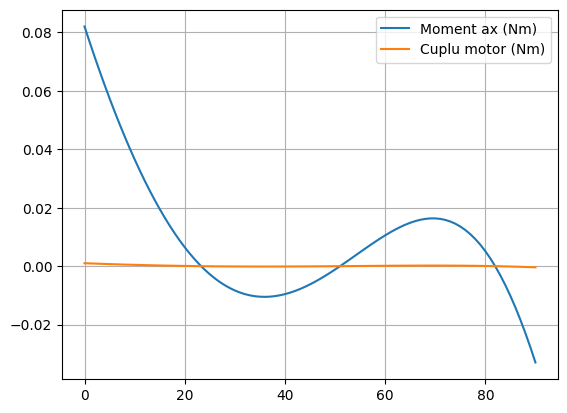

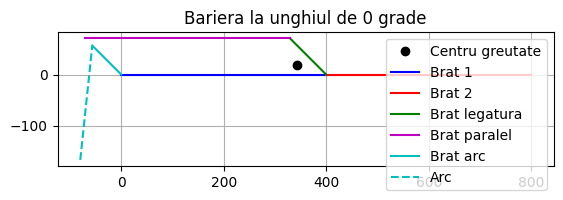

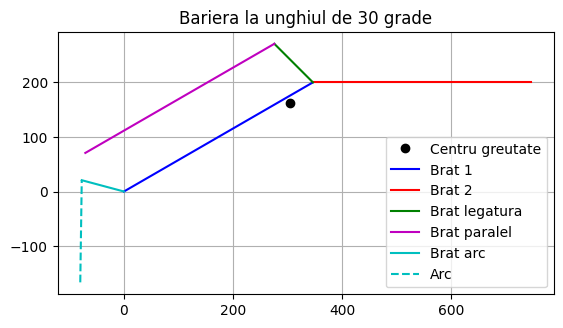

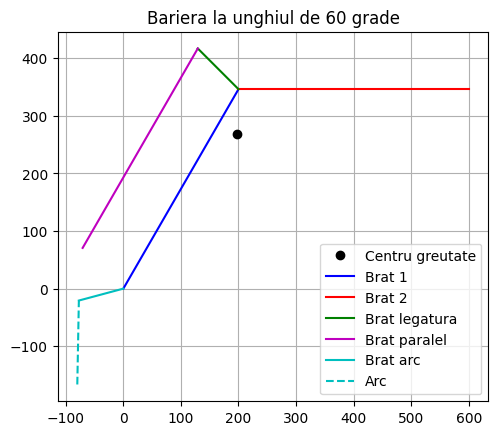

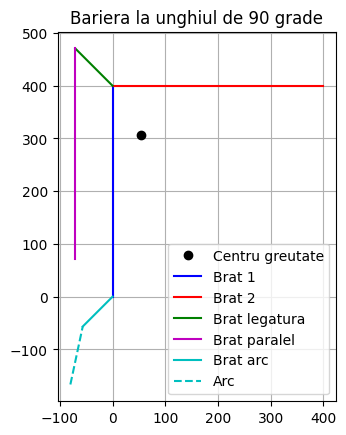

In [108]:
bariere = []
motor_maxim = 0

for unghi in range(0, 91, 1):
    bariere.append(Bariera(unghi = unghi))
    motor_maxim = max(motor_maxim, bariere[-1].cuplu_motor)

# rezultate finale
print(f'Forta necesara motor: {motor_maxim:.6f} Nm')
print(f'Forta necesara motor: {motor_maxim * 10.25:.6f} Kgcm')

# grafic moment centru de greutate vs moment arc
plt.plot([bariere[i].moment_bariera for i in range(len(bariere))])
plt.plot([bariere[i].arc.moment for i in range(len(bariere))])
plt.legend(['Moment greutate bariera (Nm)', 'Moment arc (contragreutate) (Nm)'])
plt.grid()
plt.show()

# grafic moment ax si reductor
plt.plot([bariere[i].moment_ax for i in range(len(bariere))])
plt.plot([bariere[i].cuplu_motor for i in range(len(bariere))])
plt.legend(['Moment ax (Nm)', 'Cuplu motor (Nm)'])
plt.grid()
plt.show()

# afisare bariere la unghiuri specifice
for unghi in [0, 30, 60, 90]:
    bariere[unghi].afisare()